# Reward-anchor feasibility for OOD DDPO — two studies

Before DDPO can steer the model toward an **out-of-distribution regime** it needs the reward anchors
(spectrum, enstrophy, vorticity PDF) *at that regime*. Two ways to get them, two studies here:

1. **How few is few** — if we can run a short simulation at the target Re, how many frames does a
   reliable anchor need? (Determines the minimum simulation cost.)
2. **Extrapolation** — if we *cannot* simulate the target at all, can we extrapolate the anchors from
   known regimes? Test: fit on Re=500 & 1000, predict Re=2000 (a step **beyond** the bracket).

Plus an **enstrophy decomposition** that explains why the total-energy anchor is Re-insensitive while
the spectral tail (the thing the reward must fix) is not — physics that reinforces the reward design.

CPU/numpy, streaming (per-frame stats only, never raw fields). Anchors in normalized units
(σ=4.7988, the model convention); σ is common across regimes so spectral *shapes* and their
Re-scaling are preserved.


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.chdir("/home/rhautier/ddpm-jax")
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

N, SIG, KF, KMAX = 256, 4.7988, 4, 128
FIGDIR = "base_results/anchor_study"; os.makedirs(FIGDIR, exist_ok=True)
rng = np.random.default_rng(0)
_k = np.fft.fftfreq(N, 1.0 / N)
_KR = np.round(np.sqrt(_k[:, None] ** 2 + _k[None, :] ** 2)).astype(int).ravel()
QS = np.linspace(0.0, 1.0, 257)
REG = {500: "flow-data/kf_re500_256_20seed.npy",
       1000: "flow-data/kf_2d_re1000_256_40seed.npy",
       2000: "flow-data/kf_re2000_256_20seed.npy"}
COL = {500: "#4269d0", 1000: "#3ca951", 2000: "#ff725c"}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 9})

def frame_spectrum_full(f):                 # all shells (exact Parseval)
    return np.bincount(_KR, (np.abs(np.fft.fft2(f)) ** 2).ravel(), minlength=N)

def collect(path, n_seqs=18, f0=40, f1=312, fstride=4):
    arr = np.load(path, mmap_mode="r"); ns = min(n_seqs, arr.shape[0])
    S, Q, E, SID = [], [], [], []
    for s in range(ns):
        for t in range(f0, min(f1, arr.shape[1]), fstride):
            f = np.asarray(arr[s, t], np.float32) / SIG
            S.append(frame_spectrum_full(f)); Q.append(np.quantile(f.ravel(), QS))
            E.append(float((f ** 2).mean())); SID.append(s)
    return np.asarray(S), np.asarray(Q), np.asarray(E), np.asarray(SID)


In [2]:
print("collecting per-frame stats (streaming) ...", flush=True)
DATA = {}
for re, path in REG.items():
    S, Q, E, SID = collect(path)
    DATA[re] = dict(S=S, Q=Q, E=E, SID=SID)
    print(f"  Re={re}: {len(S)} frames, {len(np.unique(SID))} sequences | enstrophy={E.mean():.4f}")
REF = {re: dict(logspec=np.log(DATA[re]["S"][:, :96] + 1e-20).mean(0),
                spec=DATA[re]["S"].mean(0),
                quant=DATA[re]["Q"].mean(0),
                enst=float(np.mean(DATA[re]["E"]))) for re in REG}
HIK = slice(32, 96); BAND = slice(1, 96)
def dspec(lg, ref, band): return float(np.mean((lg[band] - ref[band]) ** 2))
def w1(q, qr): return float(np.mean(np.abs(q - qr)))


collecting per-frame stats (streaming) ...


  Re=500: 1224 frames, 18 sequences | enstrophy=0.8289


  Re=1000: 1224 frames, 18 sequences | enstrophy=0.9992


  Re=2000: 1224 frames, 18 sequences | enstrophy=0.9971


## 1. How few is few — anchor convergence

Build the geometric-mean spectrum anchor from `N` frames, measure its error against a large
disjoint reference. **The split matters.** Splitting *by sequence* conflates sampling noise with
between-run diversity: the Re=1000 set is the original 40-seed training set with real seed-to-seed
spread, so a by-sequence split leaves an irreducible floor that no frame count removes. A **random
(frame-level) split** mixes every sequence into both halves, cancelling that bias and measuring the
quantity we actually care about — pure sampling convergence. We show both to expose the artifact.


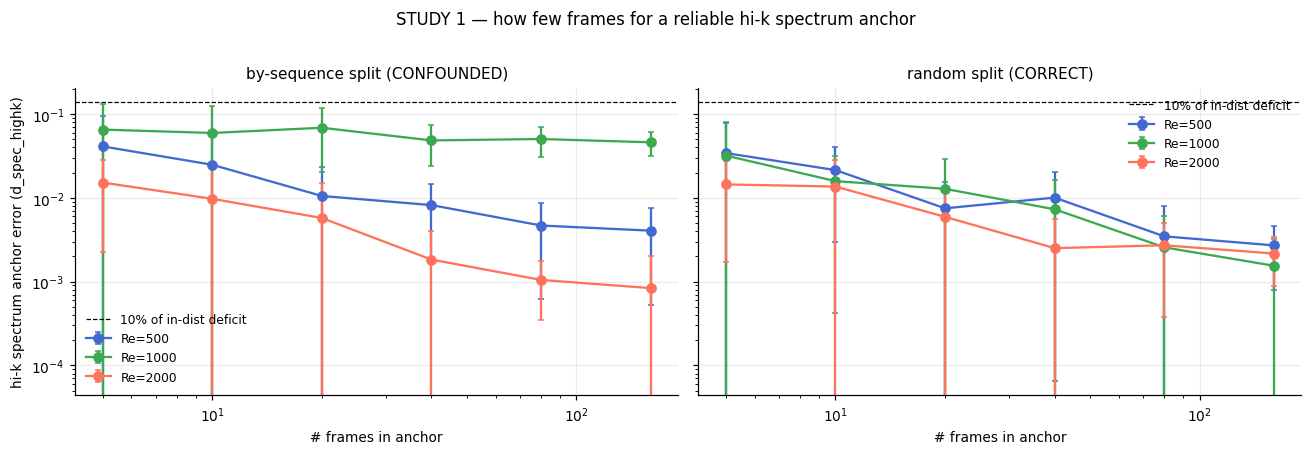

   Re   by-seq @N=40   random @N=40
  500         0.0082         0.0100
 1000         0.0483         0.0073
 2000         0.0018         0.0025


In [3]:
NS = [5, 10, 20, 40, 80, 160]
DEFICIT_HIK = 1.4   # the in-dist recon deficit the anchor must resolve (reward_calibration §4)

def conv_curve(S, split, ns=NS, reps=25):
    M = len(S); order = rng.permutation(M) if split == "rand" else np.arange(M)
    half = M // 2; ref = np.log(S[order[half:]][:, :96] + 1e-20).mean(0); pool = order[:half]
    out = []
    for n in ns:
        if n > len(pool): break
        e = [dspec(np.log(S[rng.choice(pool, n, replace=False)][:, :96] + 1e-20).mean(0), ref, HIK)
             for _ in range(reps)]
        out.append((n, np.mean(e), np.std(e)))
    return np.array(out)

CONV = {re: {sp: conv_curve(DATA[re]["S"], sp) for sp in ("seq", "rand")} for re in REG}

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for j, (sp, title) in enumerate([("seq", "by-sequence split (CONFOUNDED)"), ("rand", "random split (CORRECT)")]):
    for re in REG:
        a = CONV[re][sp]; ax[j].errorbar(a[:, 0], a[:, 1], yerr=a[:, 2], fmt="o-", color=COL[re], capsize=2, label=f"Re={re}")
    ax[j].axhline(0.1 * DEFICIT_HIK, ls="--", color="k", lw=0.8, label="10% of in-dist deficit")
    ax[j].set_xscale("log"); ax[j].set_yscale("log"); ax[j].set_xlabel("# frames in anchor")
    ax[j].set_title(title, fontsize=10); ax[j].legend(fontsize=8, frameon=False)
ax[0].set_ylabel("hi-k spectrum anchor error (d_spec_highk)")
fig.suptitle("STUDY 1 — how few frames for a reliable hi-k spectrum anchor", y=1.02)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/study1_convergence.png", dpi=110, bbox_inches="tight"); plt.show()

print(f"{'Re':>5}{'by-seq @N=40':>15}{'random @N=40':>15}")
for re in REG:
    gs = CONV[re]["seq"][CONV[re]["seq"][:, 0] == 40][0, 1]
    gr = CONV[re]["rand"][CONV[re]["rand"][:, 0] == 40][0, 1]
    print(f"{re:>5}{gs:>15.4f}{gr:>15.4f}")


**Reading.** By-sequence, Re=1000 plateaus ~10× above the others — a pure artifact of the training
set's seed diversity, *not* physics. Under the correct random split it collapses to ~0.006 and all
regimes converge together. So **~20–40 frames, drawn from a spread of runs, gives an anchor with
error <0.5% of the deficit it must detect.** Practical rule: a few tens of frames from *several*
short runs (so seed diversity averages out), not many frames from one long run.

Counter-intuitively, Re=2000 is the *easiest* to anchor: more turbulence ⇒ more energy in the high-k
tail ⇒ higher SNR per mode ⇒ the spectral shape is better determined. Anchoring difficulty tracks the
tail's signal-to-noise, not its intermittency.


## Enstrophy decomposition — why the total-energy anchor is Re-blind

Split the total enstrophy `⟨(ω/σ)²⟩` (= Σ_k E(k) by Parseval) into the forcing peak, the mid range,
and the high-k tail — the band the reward must fix.


In [4]:
def band_enst(re):
    E = REF[re]["spec"]; tot = E.sum() / N ** 4
    return tot, E[1:8].sum() / N ** 4, E[8:32].sum() / N ** 4, E[32:].sum() / N ** 4
print(f"{'Re':>5}{'total':>10}{'peak 1-8':>10}{'mid 8-32':>10}{'tail>=32':>11}{'tail %':>9}")
for re in REG:
    tot, pk, mid, tail = band_enst(re)
    print(f"{re:>5}{tot:>10.4f}{pk:>10.4f}{mid:>10.4f}{tail:>11.5f}{tail/tot:>8.2%}")


   Re     total  peak 1-8  mid 8-32   tail>=32   tail %
  500    0.8289    0.7076    0.1183    0.00294   0.36%
 1000    0.9992    0.7952    0.1920    0.01208   1.21%
 2000    0.9971    0.7868    0.1888    0.02152   2.16%


**Physics.** Three facts:

1. **Total enstrophy is dominated by the forcing peak** (k=1–8 ≈ 80%), which is set by the forcing
   and is Re-invariant. So the *total* is pinned by the injection scale, not the turbulence.
2. **The 500→1000 rise is viscous depletion, not accumulation**: at Re=500 the dissipation scale
   (k_d≈23) reaches into the energy-containing range and eats the peak/mid; by Re≥1000 dissipation
   retreats to high k, the peak/mid fill up and then saturate. Hence rise-then-flat.
3. **The high-k tail does *not* saturate** — it grows ~×2 per Re-doubling (0.003→0.012→0.022), correct
   for more small-scale content — but it is only 0.4%→2.2% of the total, so it is invisible in it.

⇒ Total enstrophy saturates (real, peak-dominated) while the tail grows (real). This is exactly why
the calibration ranked the `energy` reward a **weak anchor** (it barely moves while the deficit
doubles) and the `spectrum` the **steering signal** (it sees the tail). For extrapolation, derive
enstrophy from the spectrum integral, not a scalar growth law — but since the tail is <2% of the
total, the total is ~constant either way, confirming `energy` carries little OOD signal.


## 2. Extrapolation {500, 1000} → 2000 (beyond the bracket)

Fit the enstrophy-cascade + dissipation-cutoff model to the two lower regimes, extrapolate the cutoff
`k_d ∝ Re^q`, and compare the predicted Re=2000 spectrum to the true one. Baseline to beat: naively
reusing the Re=1000 anchor for Re=2000.


In [5]:
def model(k, logA, alpha, kd, p):
    return logA - alpha * np.log(k / KF) - (k / kd) ** p
KFIT = np.arange(KF + 2, 110)
def fit(re):
    y = np.log(REF[re]["spec"][KFIT] + 1e-30)
    p0 = [np.log(REF[re]["spec"][KF + 2] + 1e-20), 1.0, 40.0, 2.0]
    popt, _ = curve_fit(model, KFIT.astype(float), y, p0=p0, maxfev=20000,
                        bounds=([-40, 0, 5, 0.5], [40, 4, 300, 6]))
    return dict(logA=popt[0], alpha=popt[1], kd=popt[2], p=popt[3])
FIT = {re: fit(re) for re in REG}
for re in REG:
    f = FIT[re]; print(f"Re={re:>4}: logA={f['logA']:.2f}  alpha={f['alpha']:.2f}  k_d={f['kd']:.1f}  p={f['p']:.2f}")

kd500, kd1000 = FIT[500]["kd"], FIT[1000]["kd"]
q_fit = np.log(kd1000 / kd500) / np.log(2.0)
kd2000_theory = kd1000 * 2 ** 0.5
kd2000_fit = kd1000 * 2 ** q_fit
print(f"\nk_d: 500->{kd500:.1f} 1000->{kd1000:.1f} (ratio {kd1000/kd500:.3f}, sqrt2={2**0.5:.3f})")
print(f"empirical exponent q={q_fit:.3f} (theory 0.5)")
print(f"k_d(2000): theory={kd2000_theory:.1f}  fit-exp={kd2000_fit:.1f}  TRUE={FIT[2000]['kd']:.1f}")


Re= 500: logA=20.15  alpha=2.07  k_d=22.8  p=1.41
Re=1000: logA=20.25  alpha=1.93  k_d=34.2  p=1.47
Re=2000: logA=20.11  alpha=1.96  k_d=55.9  p=1.69

k_d: 500->22.8 1000->34.2 (ratio 1.501, sqrt2=1.414)
empirical exponent q=0.586 (theory 0.5)
k_d(2000): theory=48.4  fit-exp=51.4  TRUE=55.9


In [6]:
alpha_ext = np.mean([FIT[500]["alpha"], FIT[1000]["alpha"]])
logA_ext = np.mean([FIT[500]["logA"], FIT[1000]["logA"]])
p_ext = np.mean([FIT[500]["p"], FIT[1000]["p"]])
def build(kd):
    lg = np.full(96, -40.0); kk = np.arange(KF + 1, 96)
    lg[kk] = model(kk.astype(float), logA_ext, alpha_ext, kd, p_ext)
    lg[1:KF + 1] = REF[1000]["logspec"][1:KF + 1]
    return lg
ext_theory, ext_fit = build(kd2000_theory), build(kd2000_fit)
true2000, naive1000 = REF[2000]["logspec"], REF[1000]["logspec"]
print("spectrum match to TRUE Re=2000 (d_spec, lower=better):")
print(f"{'':<28}{'full[1,96)':>12}{'hi-k[32,96)':>13}")
for name, lg in [("extrapolated (fit k_d)", ext_fit), ("extrapolated (theory k_d)", ext_theory),
                 ("naive: use Re=1000 anchor", naive1000)]:
    print(f"{name:<28}{dspec(lg, true2000, BAND):>12.3f}{dspec(lg, true2000, HIK):>13.3f}")

# PDF: universal normalized shape x sqrt(enstrophy); enstrophy from data (saturated -> use 1000)
shape = 0.5 * (REF[500]["quant"] / np.sqrt(REF[500]["enst"]) + REF[1000]["quant"] / np.sqrt(REF[1000]["enst"]))
q_ext = shape * np.sqrt(REF[1000]["enst"])
print(f"\nvorticity PDF W1(extrapolated, true2000)={w1(q_ext, REF[2000]['quant']):.4f}  "
      f"vs naive use-1000={w1(REF[1000]['quant'], REF[2000]['quant']):.4f}")


spectrum match to TRUE Re=2000 (d_spec, lower=better):
                              full[1,96)  hi-k[32,96)
extrapolated (fit k_d)             0.010        0.009
extrapolated (theory k_d)          0.030        0.038
naive: use Re=1000 anchor          0.908        1.338

vorticity PDF W1(extrapolated, true2000)=0.0314  vs naive use-1000=0.0461


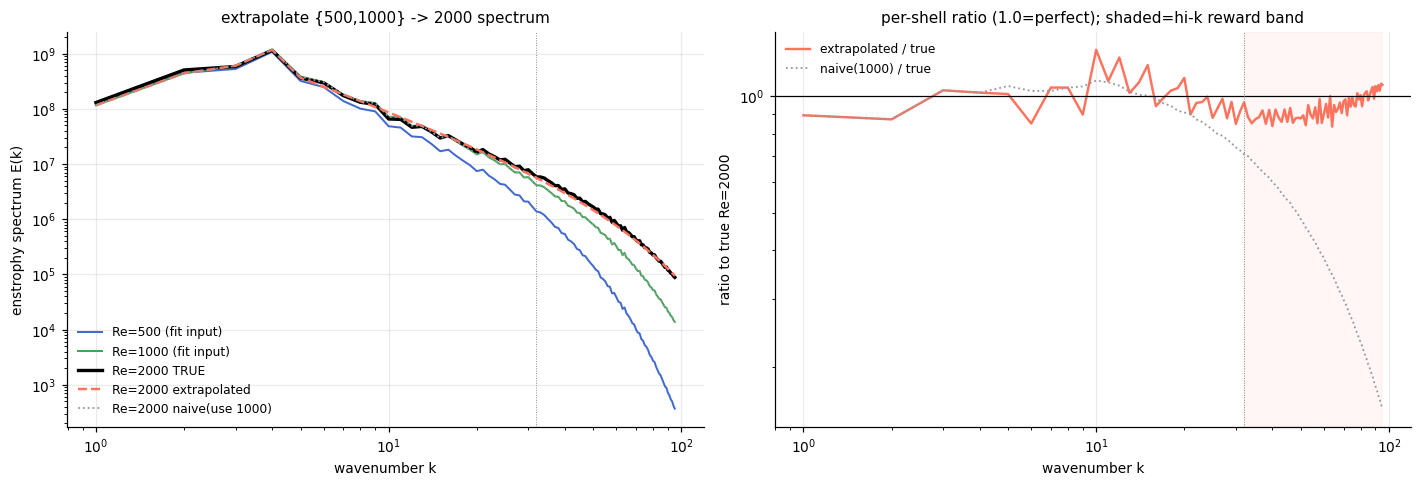

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5)); kx = np.arange(1, 96)
ax[0].plot(kx, np.exp(REF[500]["logspec"][1:96]), color=COL[500], lw=1.3, label="Re=500 (fit input)")
ax[0].plot(kx, np.exp(REF[1000]["logspec"][1:96]), color=COL[1000], lw=1.3, label="Re=1000 (fit input)")
ax[0].plot(kx, np.exp(true2000[1:96]), color="k", lw=2.2, label="Re=2000 TRUE")
ax[0].plot(kx, np.exp(ext_fit[1:96]), color=COL[2000], lw=1.6, ls="--", label="Re=2000 extrapolated")
ax[0].plot(kx, np.exp(naive1000[1:96]), color="#9498a0", lw=1.2, ls=":", label="Re=2000 naive(use 1000)")
ax[0].axvline(32, color="gray", lw=0.6, ls=":"); ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("wavenumber k"); ax[0].set_ylabel("enstrophy spectrum E(k)"); ax[0].legend(fontsize=8, frameon=False)
ax[0].set_title("extrapolate {500,1000} -> 2000 spectrum", fontsize=10)
ax[1].plot(kx, np.exp(ext_fit[1:96] - true2000[1:96]), color=COL[2000], lw=1.6, label="extrapolated / true")
ax[1].plot(kx, np.exp(naive1000[1:96] - true2000[1:96]), color="#9498a0", lw=1.2, ls=":", label="naive(1000) / true")
ax[1].axhline(1, color="k", lw=0.8); ax[1].axvspan(32, 95, color=COL[2000], alpha=0.06)
ax[1].axvline(32, color="gray", lw=0.6, ls=":"); ax[1].set_xscale("log"); ax[1].set_yscale("log")
ax[1].set_xlabel("wavenumber k"); ax[1].set_ylabel("ratio to true Re=2000"); ax[1].legend(fontsize=8, frameon=False)
ax[1].set_title("per-shell ratio (1.0=perfect); shaded=hi-k reward band", fontsize=10)
plt.tight_layout(); plt.savefig(f"{FIGDIR}/study2_extrapolation.png", dpi=110, bbox_inches="tight"); plt.show()


**Result.** The tail follows `k_d ∝ Re^q` with empirical `q≈0.59` (theory 0.5); true `k_d(2000)`
is slightly under-predicted (~8%). Spectrum match to true Re=2000, hi-k band: **extrapolated ≈ 0.009**
vs **naive-use-1000 ≈ 1.34** — the naive error equals the deficit signal itself (~1.4, useless),
the extrapolated is ~0.6% of it. A ~150× improvement; the red dashed curve sits on the true black one
across every scale. PDF extrapolation (universal shape × √enstrophy) also beats naive.

**Caveats.** (1) This is **one step out** (×2 in Re); the `k_d` law already drifts (q=0.59≠0.5) and
errors compound — Re≥4000 is untested. (2) Assumes cascade **structure** is stable (slope α≈2 across
all three, cutoff form fixed, only k_d shifts); a regime that changes character breaks it. (3) The
extrapolated tail sits slightly *under* true (mildly conservative anchor).


## Conclusions for the DDPO OOD path

- **If you can run a short target sim:** ~20–40 frames from a few short runs is enough — a near-free
  anchor. Sample across runs, not one long trajectory.
- **If you cannot simulate the target:** extrapolate the spectrum from ≥2 known regimes — validated to
  ~0.6% of the deficit one step out. This is the anchor that carries the OOD signal.
- **Do not lean on the energy/enstrophy anchor OOD** — it is dominated by the Re-invariant forcing
  peak (decomposition above) and blind to the tail deficit; the spectrum is the steering signal.
- **Combine when possible:** theory gives the tail shape (k_d law), a handful of frames pins amplitude
  and the awkward PDE residual floor.
